In [3]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from lightgbm import LGBMRegressor
import xgboost as xgb
from xgboost import XGBRegressor
from xgboost import plot_importance
import shap
import warnings
warnings.filterwarnings('ignore')

**Reading The Data**

In [5]:
df = pd.read_csv("Downloads/Walmart Dataset/Walmart_Sales.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


**Exploratory Data Analysis**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [9]:
df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")

In [11]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


**Visualizations for Discovering Patterns**

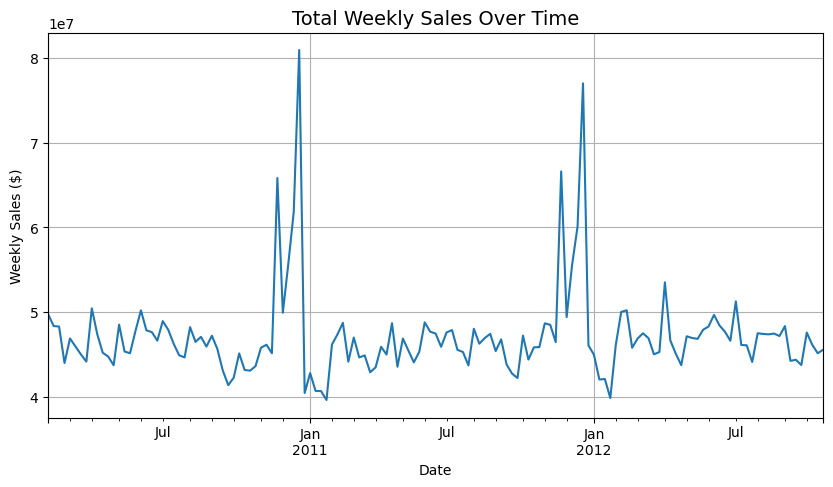

In [13]:
df1 = df.sort_values(by="Date")

plt.figure(figsize=(10,5))
df1.groupby("Date")["Weekly_Sales"].sum().plot()
plt.title("Total Weekly Sales Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Weekly Sales ($)")
plt.grid(True)
plt.show()

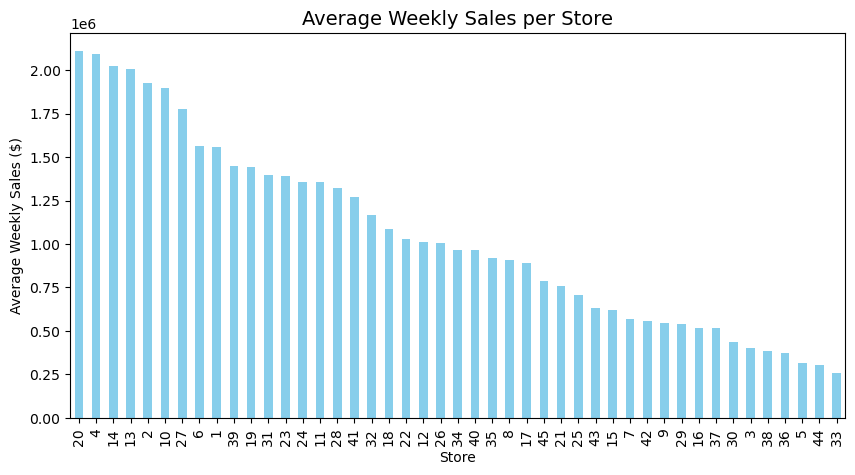

In [15]:
plt.figure(figsize=(10,5))
avg_sales = df1.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False)
avg_sales.plot(kind='bar', color='skyblue')
plt.title("Average Weekly Sales per Store", fontsize=14)
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales ($)")
plt.show()

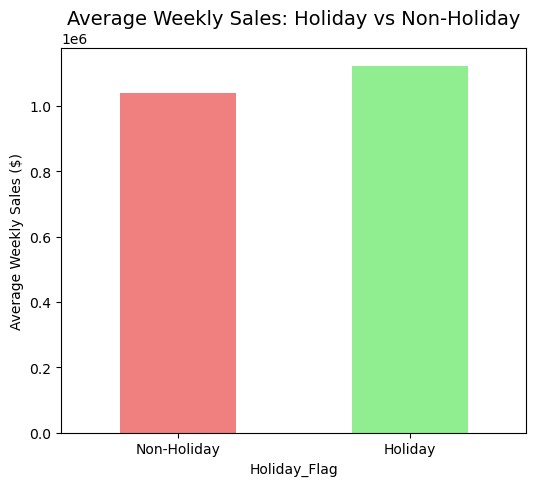

In [17]:
plt.figure(figsize=(6,5))
df1.groupby("Holiday_Flag")["Weekly_Sales"].mean().plot(
    kind='bar', color=['lightcoral', 'lightgreen'])
plt.title("Average Weekly Sales: Holiday vs Non-Holiday", fontsize=14)
plt.xticks([0,1], ["Non-Holiday", "Holiday"], rotation=0)
plt.ylabel("Average Weekly Sales ($)")
plt.show()

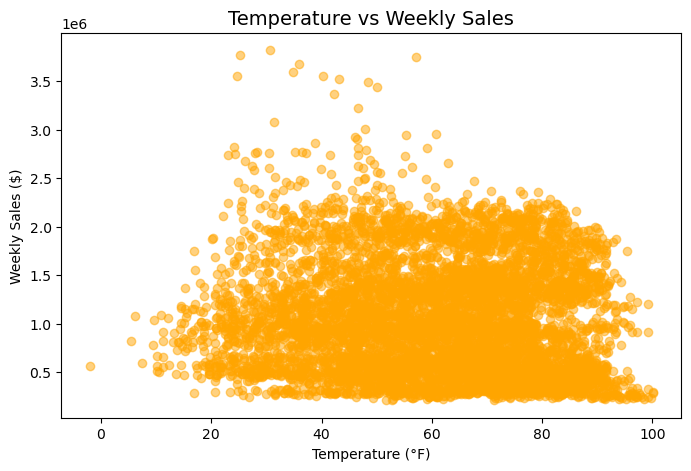

In [19]:
plt.figure(figsize=(8,5))
plt.scatter(df1["Temperature"], df1["Weekly_Sales"], alpha=0.5, color='orange')
plt.title("Temperature vs Weekly Sales", fontsize=14)
plt.xlabel("Temperature (°F)")
plt.ylabel("Weekly Sales ($)")
plt.show()

**Feature Engineering Date Column to facilitate building Models**

In [22]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Day'] = df['Date'].dt.day

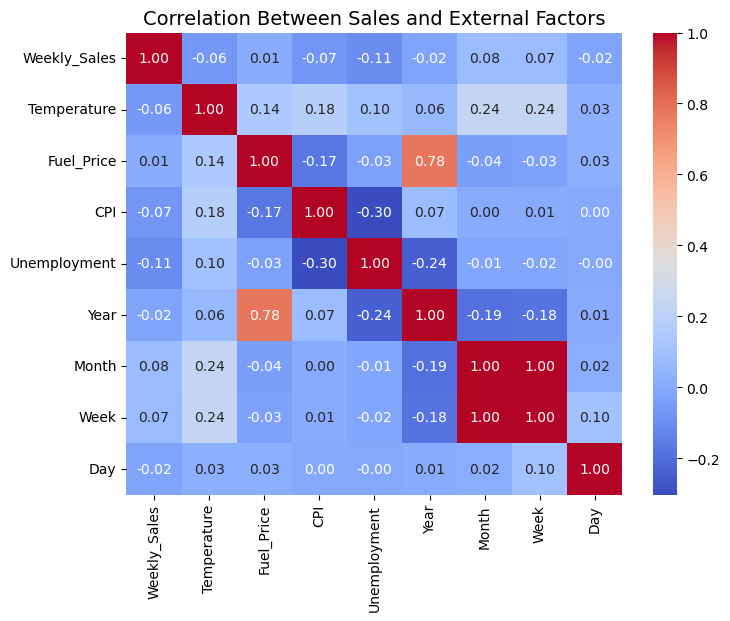

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment','Year', 'Month', 'Week', 'Day']].corr(),
    annot=True, cmap="coolwarm", fmt=".2f"
)
plt.title("Correlation Between Sales and External Factors", fontsize=14)
plt.show()

**Data Preprocessing for building Models**

In [27]:
df2=df.drop('Date', axis=1)
df2.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Day
0,1,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,5
1,1,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,12
2,1,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,19
3,1,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,26
4,1,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,5


In [29]:
X = df2.drop('Weekly_Sales', axis=1)
y = df2['Weekly_Sales']

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.3, random_state = 123)

**Building and Evaluating Ensemble Models**

In [33]:
RFR = RandomForestRegressor(random_state = 123)
RFR_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
RFR_grid = GridSearchCV(RFR, RFR_params, cv=5, scoring='r2', n_jobs=-1, verbose=1)
RFR_grid.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=123), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='r2', verbose=1)

In [35]:
RF = RFR_grid.best_estimator_
print("Best RF Params:", RFR_grid.best_params_)
print("Best RF R2 Score:", RFR_grid.best_score_)

Best RF Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RF R2 Score: 0.9633160564456702


In [37]:
LGBMR = LGBMRegressor(random_state = 123)
LGBMR_params = {
    'n_estimators': [200, 300, 400],
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.05, 0.01],
    'num_leaves': [31, 50, 100],
    'subsample': [0.8, 1.0]
}
LGBMR_grid = GridSearchCV(LGBMR, LGBMR_params, cv=5, scoring='r2', n_jobs=-1, verbose=1)
LGBMR_grid.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000430 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1161
[LightGBM] [Info] Number of data points in the train set: 4504, number of used features: 10
[LightGBM] [Info] Start training from score 1043966.528731
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

GridSearchCV(cv=5, estimator=LGBMRegressor(random_state=123), n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.01],
                         'max_depth': [-1, 10, 20],
                         'n_estimators': [200, 300, 400],
                         'num_leaves': [31, 50, 100], 'subsample': [0.8, 1.0]},
             scoring='r2', verbose=1)

In [39]:
LGBM = LGBMR_grid.best_estimator_
print("Best LGBM Params:", LGBMR_grid.best_params_)
print("Best LGBM R2 Score:", LGBMR_grid.best_score_)

Best LGBM Params: {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 400, 'num_leaves': 100, 'subsample': 0.8}
Best LGBM R2 Score: 0.975375012053836


In [41]:
XGBR = XGBRegressor(random_state = 123, objective='reg:squarederror')
XGBR_params = {
    'n_estimators': [200, 300, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.01],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}
XGBR_grid = GridSearchCV(XGBR, XGBR_params, cv=5, scoring='r2', n_jobs=-1, verbose=1)
XGBR_grid.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1],
                         'learning_rate': [0.05, 0.01], 'max_depth': [3, 5, 7],
                         'n_estimators': [200, 300, 400],
                         'subsample': [0.8, 1]},
             scoring='r2', verbose=1)

In [43]:
XGB = XGBR_grid.best_estimator_
print("Best XGB Params:", XGBR_grid.best_params_)
print("Best XGB R2 Score:", XGBR_grid.best_score_)

Best XGB Params: {'colsample_bytree': 1, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 400, 'subsample': 0.8}
Best XGB R2 Score: 0.9774840868059991


In [47]:
Models = {
    "Random Forest": RF,
    "LightGBM": LGBM,
    "XGBoost": XGB
}

for name, model in Models.items():
    preds = model.predict(X_test)
    print(f"\n{name} Performance:")
    print(f"R² Score: {metrics.r2_score(y_test, preds):.4f}")
    print(f"RMSE: {metrics.root_mean_squared_error(y_test, preds):.2f}")


Random Forest Performance:
R² Score: 0.9610
RMSE: 113089.64

LightGBM Performance:
R² Score: 0.9760
RMSE: 88769.40

XGBoost Performance:
R² Score: 0.9761
RMSE: 88584.41


**Feature Importance of each Model to determine most important factor for Sales in each Model**

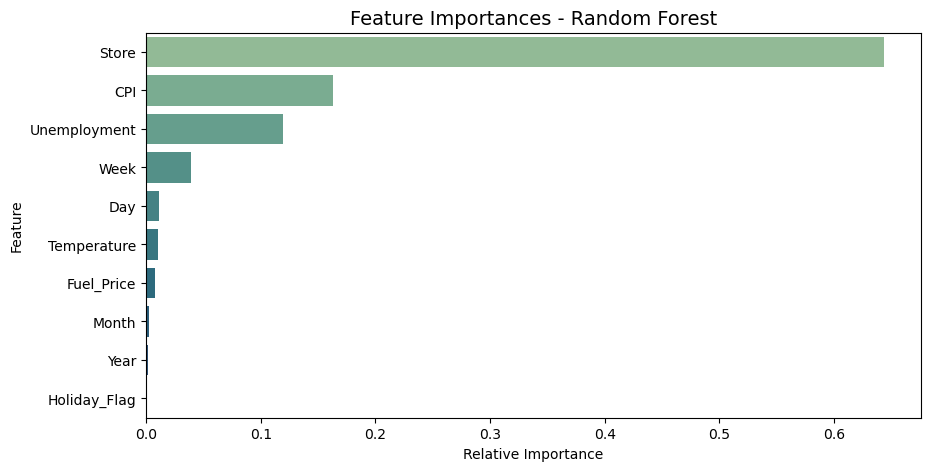

In [50]:
RF_importances = RF.feature_importances_

RF_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': RF_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=RF_imp_df, palette='crest')
plt.title("Feature Importances - Random Forest", fontsize=14)
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.show()

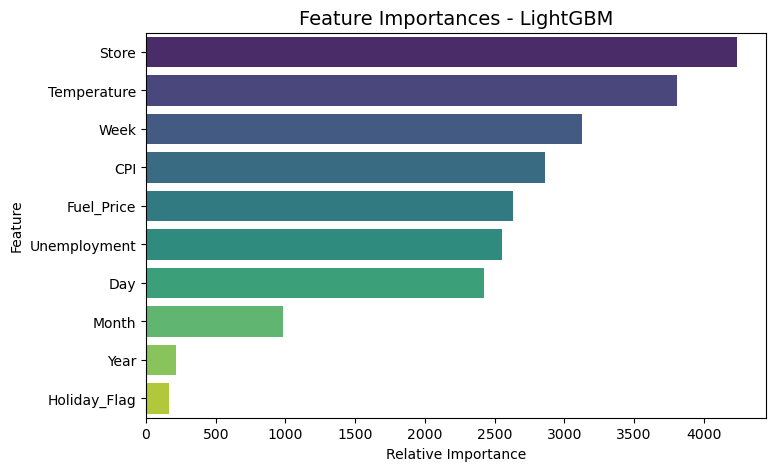

In [52]:
LGBM_importances = LGBM.feature_importances_

LGBM_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': LGBM_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=LGBM_imp_df, palette='viridis')
plt.title("Feature Importances - LightGBM", fontsize=14)
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.show()

<Figure size 1000x500 with 0 Axes>

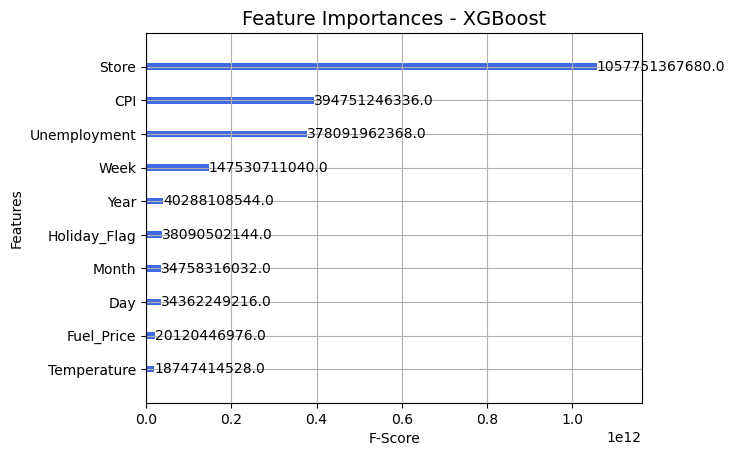

In [54]:
plt.figure(figsize=(10,5))
plot_importance(XGB, importance_type='gain', color='royalblue')
plt.title("Feature Importances - XGBoost", fontsize=14)
plt.xlabel("F-Score")
plt.show()

**Shap Values to understand how each feature impacts Predicted Sales in each Model**

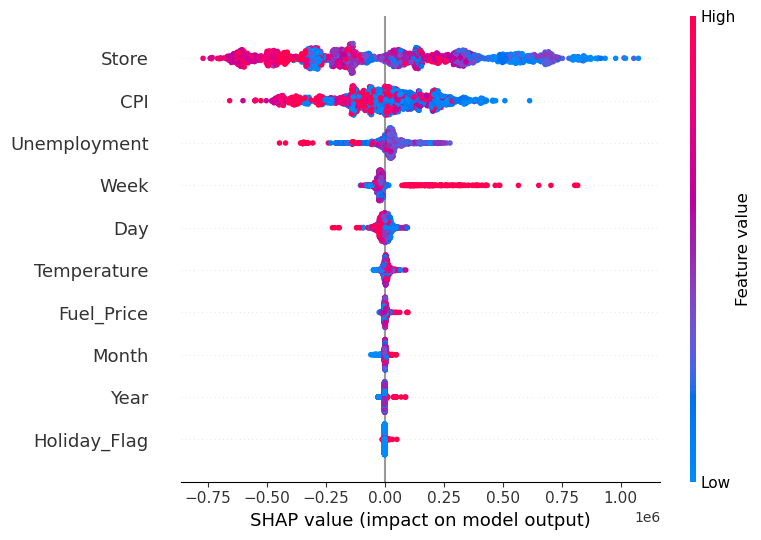

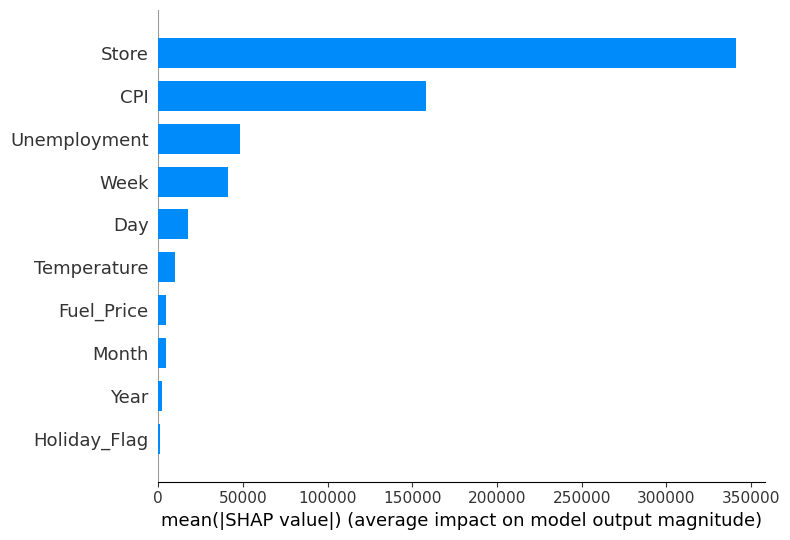

In [56]:
explainer_RF = shap.TreeExplainer(RF)
shap_values_RF = explainer_RF.shap_values(X_test)

plt.title("SHAP Summary Plot - Random Forest")
shap.summary_plot(shap_values_RF, X_test, plot_type="dot", show=True)

plt.title("SHAP Feature Importance - Random Forest")
shap.summary_plot(shap_values_RF, X_test, plot_type="bar", show=True)

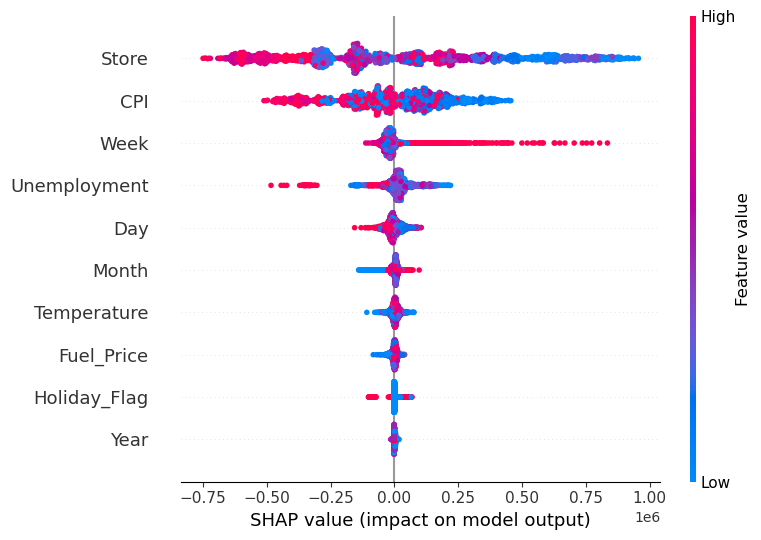

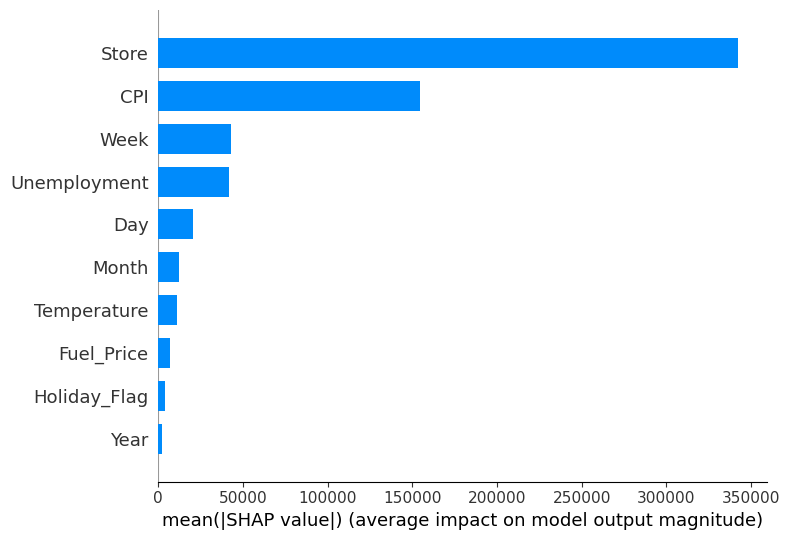

In [58]:
explainer_LGBM = shap.TreeExplainer(LGBM)
shap_values_LGBM = explainer_LGBM.shap_values(X_test)

plt.title("SHAP Summary Plot - LightGBM")
shap.summary_plot(shap_values_LGBM, X_test, plot_type="dot", show=True)

plt.title("SHAP Feature Importance - LightGBM")
shap.summary_plot(shap_values_LGBM, X_test, plot_type="bar", show=True)

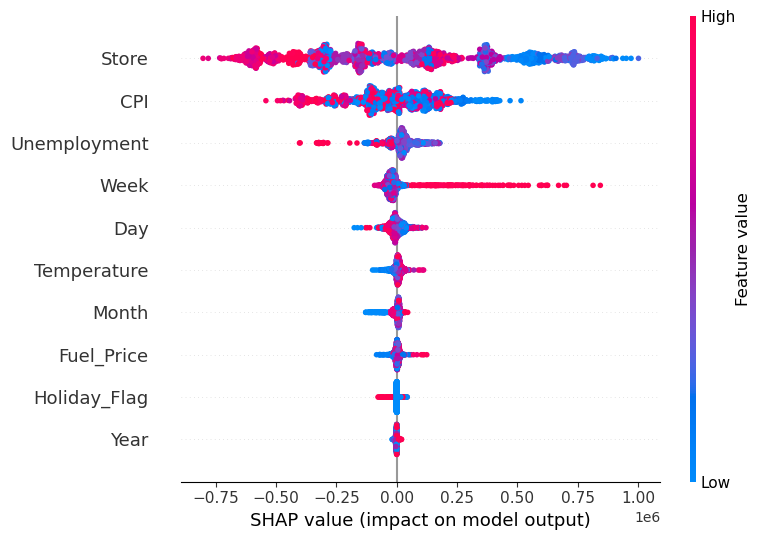

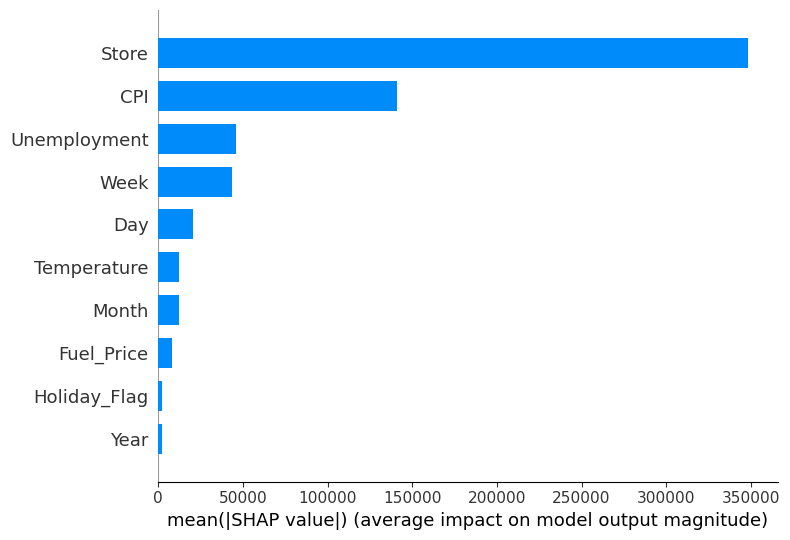

In [60]:
explainer_XGB = shap.TreeExplainer(XGB)
shap_values_XGB = explainer_XGB.shap_values(X_test)

plt.title("SHAP Summary Plot - XGBoost")
shap.summary_plot(shap_values_XGB, X_test, plot_type="dot", show=True)

plt.title("SHAP Feature Importance - XGBoost")
shap.summary_plot(shap_values_XGB, X_test, plot_type="bar", show=True)